# Master Test Notebook - Planner, Database, Forecasting, Analytics, Form Checker

One notebook, run top to bottom. Covers:
1. Core planner logic (bmr_tdee, diet_logic, workout_logic)
2. Database layer (connection, insert, fetch, constraints)
3. Forecasting (Prophet)
4. Analytics functions + adherence/calories-vs-weight correlation
5. Form checker (angle math + video pipeline for squat/deadlift/push-up)

**Before running:** confirm `.env` is correct, tables exist (`sql/create_tables.sql` + `sql/add_form_checks_table.sql` have been run), and seed data is imported. Set `DEMO_USER_ID` below to your actual seeded user's ID. For Part 5, you'll need recorded exercise videos - update the `VIDEO_PATH` variables in that section.

**Habit:** Restart Kernel → Run All before trusting results - don't rely on out-of-order cell execution.

In [61]:
import sys
sys.path.append('.')

import pandas as pd
from datetime import date, timedelta
from scipy import stats

from modules.bmr_tdee import calculate_bmr, calculate_tdee, calculate_bmi
from modules.diet_logic import get_diet_plan
from modules.workout_logic import get_workout_split
from modules.database import (
    get_connection, insert_user, insert_daily_log, get_user_by_id, get_logs_for_user
)
from modules.analytics import get_weekly_adherence, get_rolling_weight_trend, get_weekly_activity
from modules.forecasting import prepare_prophet_input, fit_and_forecast, generate_forecast_chart, get_forecast_summary
from modules.form_checker import calculate_angle, process_video

DEMO_USER_ID = 1  # <-- change this to your actual seeded demo user's user_id (used in Parts 3 & 4)

---
# PART 1 - Core Planner Logic

## 1.1 BMR / TDEE / BMI - normal cases

Check at least one of these against a trusted online TDEE calculator.

In [62]:
test_users = [
    {"weight_kg": 70, "height_cm": 170, "age": 25, "gender": "male", "activity_level": "moderately_active"},
    {"weight_kg": 58, "height_cm": 160, "age": 22, "gender": "female", "activity_level": "lightly_active"},
    {"weight_kg": 85, "height_cm": 180, "age": 30, "gender": "male", "activity_level": "very_active"},
]

for user in test_users:
    bmr = calculate_bmr(user["weight_kg"], user["height_cm"], user["age"], user["gender"])
    tdee = calculate_tdee(bmr, user["activity_level"])
    bmi = calculate_bmi(user["weight_kg"], user["height_cm"])
    print(f"{user}")
    print(f"  BMR: {bmr:.1f} kcal | TDEE: {tdee:.1f} kcal | BMI: {bmi:.1f}\n")

{'weight_kg': 70, 'height_cm': 170, 'age': 25, 'gender': 'male', 'activity_level': 'moderately_active'}
  BMR: 1642.5 kcal | TDEE: 2545.9 kcal | BMI: 24.2

{'weight_kg': 58, 'height_cm': 160, 'age': 22, 'gender': 'female', 'activity_level': 'lightly_active'}
  BMR: 1309.0 kcal | TDEE: 1799.9 kcal | BMI: 22.7

{'weight_kg': 85, 'height_cm': 180, 'age': 30, 'gender': 'male', 'activity_level': 'very_active'}
  BMR: 1830.0 kcal | TDEE: 3156.8 kcal | BMI: 26.2



## 1.2 BMR / TDEE - edge cases (should raise ValueError)

In [63]:
print(calculate_bmr(70, 170, 25, "Male "))  # normalized casing/whitespace should still work

try:
    calculate_bmr(70, 170, 25, "banana")
    print("FAILED: should have raised ValueError")
except ValueError as e:
    print(f"OK  - correctly raised: {e}")

try:
    calculate_tdee(1600, "lightly active")  # space instead of underscore, should normalize
    print("OK  - normalized space to underscore")
except ValueError as e:
    print(f"FAILED unexpectedly: {e}")

try:
    calculate_tdee(1600, "super_active")  # not a real key
    print("FAILED: should have raised ValueError")
except ValueError as e:
    print(f"OK  - correctly raised: {e}")

1642.5
OK  - correctly raised: Invalid gender: 'banana'. Expected 'male' or 'female'.
OK  - normalized space to underscore
OK  - correctly raised: Invalid activity level: 'super_active'. Expected one of ['sedentary', 'lightly_active', 'moderately_active', 'very_active', 'extra_active'].


## 1.3 Diet plan - all three goals

Manually check: does protein_g×4 + carbs_g×4 + fat_g×9 land close to calorie_target?

In [64]:
sample_tdee = 2200

for goal in ["muscle_gain", "fat_loss", "maintenance"]:
    plan = get_diet_plan(sample_tdee, goal)
    check = plan["protein_g"] * 4 + plan["carbs_g"] * 4 + plan["fat_g"] * 9
    print(f"Goal: {goal}")
    print(f"  {plan}")
    print(f"  Reconstructed calories: {check:.0f} (target was {plan['calorie_target']})\n")

Goal: muscle_gain
  {'calorie_target': 2500, 'protein_g': 187.5, 'carbs_g': 281.2, 'fat_g': 69.4}
  Reconstructed calories: 2499 (target was 2500)

Goal: fat_loss
  {'calorie_target': 1700, 'protein_g': 170.0, 'carbs_g': 127.5, 'fat_g': 56.7}
  Reconstructed calories: 1700 (target was 1700)

Goal: maintenance
  {'calorie_target': 2200, 'protein_g': 165.0, 'carbs_g': 220.0, 'fat_g': 73.3}
  Reconstructed calories: 2200 (target was 2200)



## 1.4 Workout split - check logic across goal x experience combos

In [65]:
combos = [
    ("muscle_gain", "advanced"),
    ("fat_loss", "beginner"),
    ("maintenance", "intermediate"),
]

for goal, level in combos:
    print(f"=== Goal: {goal} | Experience: {level} ===")
    split = get_workout_split(goal, level)
    for day, details in split.items():
        if details["type"] == "rest":
            print(f"  {day}: Rest")
        else:
            print(f"  {day}: {details['type']}  - {details['sets']}x{details['reps']}, rest {details['rest_seconds']}s")
    print()

=== Goal: muscle_gain | Experience: advanced ===
  Monday: push  - 4x8-12, rest 90s
  Tuesday: pull  - 4x8-12, rest 90s
  Wednesday: legs  - 4x8-12, rest 90s
  Thursday: Rest
  Friday: push  - 4x8-12, rest 90s
  Saturday: pull  - 4x8-12, rest 90s
  Sunday: legs  - 4x8-12, rest 90s

=== Goal: fat_loss | Experience: beginner ===
  Monday: full_body  - 3x12-15, rest 45s
  Tuesday: Rest
  Wednesday: full_body  - 3x12-15, rest 45s
  Thursday: Rest
  Friday: full_body  - 3x12-15, rest 45s
  Saturday: Rest
  Sunday: Rest

=== Goal: maintenance | Experience: intermediate ===
  Monday: upper  - 3x8-12, rest 60s
  Tuesday: lower  - 3x8-12, rest 60s
  Wednesday: Rest
  Thursday: upper  - 3x8-12, rest 60s
  Friday: lower  - 3x8-12, rest 60s
  Saturday: Rest
  Sunday: Rest



## 1.5 Full end-to-end - one simulated user through all three planner modules

In [66]:
sim_user = {
    "weight_kg": 65, "height_cm": 165, "age": 24, "gender": "female",
    "activity_level": "moderately_active", "goal": "fat_loss", "experience_level": "beginner"
}

bmr = calculate_bmr(sim_user["weight_kg"], sim_user["height_cm"], sim_user["age"], sim_user["gender"])
tdee = calculate_tdee(bmr, sim_user["activity_level"])
diet_plan = get_diet_plan(tdee, sim_user["goal"])
workout_split = get_workout_split(sim_user["goal"], sim_user["experience_level"])

print(f"BMR: {bmr:.1f} | TDEE: {tdee:.1f}\n")
print(f"Diet plan: {diet_plan}\n")
print("Workout split:")
for day, details in workout_split.items():
    print(f"  {day}: {details['type']}")

BMR: 1400.2 | TDEE: 2170.4

Diet plan: {'calorie_target': 1670, 'protein_g': 167.0, 'carbs_g': 125.3, 'fat_g': 55.7}

Workout split:
  Monday: full_body
  Tuesday: rest
  Wednesday: full_body
  Thursday: rest
  Friday: full_body
  Saturday: rest
  Sunday: rest


---
# PART 2 - Database Layer

## 2.1 Test the raw connection

If this fails, fix it before running the rest of Part 2.

In [67]:
try:
    conn = get_connection()
    print("Connection successful:", conn.is_connected())
    conn.close()
except ConnectionError as e:
    print(f"Connection FAILED: {e}")
    print("Check .env  - DB_HOST, DB_PORT, DB_USER, DB_PASSWORD, DB_NAME")

Connection successful: True


## 2.2 Insert a test user, fetch it back

In [68]:
test_user_id = insert_user(
    name="Test User", age=25, gender="female", height_cm=165, weight_kg=60,
    activity_level="moderately_active", goal="fat_loss", dietary_pref="vegetarian"
)
print(f"Inserted user with user_id: {test_user_id}")

fetched_user = get_user_by_id(test_user_id)
print(f"Fetched back: {fetched_user}")

assert fetched_user is not None, "FAILED: user not found after insert"
assert fetched_user["name"] == "Test User", "FAILED: name mismatch"
assert fetched_user["goal"] == "fat_loss", "FAILED: goal mismatch"
print("\nAll checks passed.")

Inserted user with user_id: 10
Fetched back: {'user_id': 10, 'name': 'Test User', 'age': 25, 'gender': 'female', 'height_cm': Decimal('165.00'), 'weight_kg': Decimal('60.00'), 'activity_level': 'moderately_active', 'goal': 'fat_loss', 'dietary_pref': 'vegetarian', 'created_at': datetime.datetime(2026, 8, 30, 17, 54, 30)}

All checks passed.


## 2.3 Insert a week of daily logs

In [69]:
start_date = date.today() - timedelta(days=6)
starting_weight = 60.0

for i in range(7):
    log_date = start_date + timedelta(days=i)
    weight = starting_weight - (i * 0.1)
    log_id = insert_daily_log(
        user_id=test_user_id, log_date=log_date, weight_kg=round(weight, 1),
        calories_consumed=1800 + (i * 10), protein_g=120, carbs_g=150, fat_g=55,
        workout_completed=(i % 2 == 0), steps_walked=7000 + (i * 200),
        notes=f"Day {i+1} test log"
    )
    print(f"Inserted log_id {log_id} for {log_date}, weight {weight:.1f}kg")

Inserted log_id 233 for 2026-08-24, weight 60.0kg
Inserted log_id 234 for 2026-08-25, weight 59.9kg
Inserted log_id 235 for 2026-08-26, weight 59.8kg
Inserted log_id 236 for 2026-08-27, weight 59.7kg
Inserted log_id 237 for 2026-08-28, weight 59.6kg
Inserted log_id 238 for 2026-08-29, weight 59.5kg
Inserted log_id 239 for 2026-08-30, weight 59.4kg


## 2.4 Fetch logs back, check ordering

In [70]:
fetched_logs = get_logs_for_user(test_user_id)
print(f"Fetched {len(fetched_logs)} logs (expected 7)")

assert len(fetched_logs) == 7, f"FAILED: expected 7 logs, got {len(fetched_logs)}"
assert fetched_logs[0]['log_date'] > fetched_logs[-1]['log_date'], "FAILED: not ordered most-recent-first"
print("All checks passed.")

Fetched 7 logs (expected 7)
All checks passed.


## 2.5 Test the `limit` parameter

In [71]:
recent_3 = get_logs_for_user(test_user_id, limit=3)
assert len(recent_3) == 3, f"FAILED: expected 3, got {len(recent_3)}"
print("OK")

OK


## 2.6 Test the unique_user_date constraint

Should raise - this confirms the schema constraint is actually enforced.

In [72]:
try:
    insert_daily_log(user_id=test_user_id, log_date=start_date, weight_kg=59.9)
    print("FAILED: duplicate insert should have raised an error")
except Exception as e:
    print(f"OK  - correctly rejected duplicate: {type(e).__name__}: {e}")

OK  - correctly rejected duplicate: IntegrityError: 1062 (23000): Duplicate entry '10-2026-08-24' for key 'daily_logs.unique_user_date'


## 2.7 Cleanup - deletes the test user (cascades to their logs)

Run this before moving on, or re-running Part 2 later will hit the unique_user_date constraint on old leftover data.

In [73]:
conn = get_connection()
cursor = conn.cursor()
cursor.execute("DELETE FROM users WHERE user_id = %s", (test_user_id,))
conn.commit()

remaining_logs = get_logs_for_user(test_user_id)
assert len(remaining_logs) == 0, "FAILED: cascade delete did not remove logs"
print(f"Deleted test user {test_user_id}, cascade delete confirmed working.")

cursor.close()
conn.close()

Deleted test user 10, cascade delete confirmed working.


---
# PART 3 - Forecasting (Prophet)

Uses `DEMO_USER_ID` from the top of the notebook - your real seeded demo user, not the throwaway test user from Part 2.

## 3.1 Check the input shape before fitting anything

Confirms `ds`/`y` columns exist and dates look right - catch a data problem here, not three cells later inside Prophet's error output.

In [74]:
prophet_input = prepare_prophet_input(DEMO_USER_ID)
print(f"{len(prophet_input)} rows of history")
print(prophet_input.head())
print(prophet_input.dtypes)

200 rows of history
          ds     y
0 2025-01-01  71.5
1 2025-01-02  69.6
2 2025-01-03  71.9
3 2025-01-04  74.6
4 2025-01-05  69.3
ds    datetime64[ns]
y            float64
dtype: object


c:\Users\Divya\Documents\workout_planner\modules\analytics.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


## 3.2 Fit the model and forecast

This will print Prophet's own fitting log (informational, not an error) - that's normal.

In [75]:
model, forecast = fit_and_forecast(DEMO_USER_ID, periods_days=28)

print(f"Forecast dataframe shape: {forecast.shape}")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))
17:54:31 - cmdstanpy - INFO - Chain [1] start processing
17:54:31 - cmdstanpy - INFO - Chain [1] done processing


Forecast dataframe shape: (228, 16)
            ds       yhat  yhat_lower  yhat_upper
218 2025-08-07  70.912116   67.616023   74.501585
219 2025-08-08  69.868201   66.358348   73.272080
220 2025-08-09  70.713989   67.413991   74.083398
221 2025-08-10  69.673562   66.216091   73.089668
222 2025-08-11  70.706679   67.278255   74.199892
223 2025-08-12  70.600316   67.008009   73.901186
224 2025-08-13  69.559655   66.217073   72.987202
225 2025-08-14  70.936490   67.457062   74.507684
226 2025-08-15  69.892574   66.451133   73.209652
227 2025-08-16  70.738362   67.281061   74.144213


## 3.3 Sanity checks

Basic assertions - not exhaustive, but catches obviously broken output (e.g. a forecast that's flat-zero or wildly diverging).

In [76]:
assert forecast['yhat'].notna().all(), "FAILED: forecast contains null predictions"
assert (forecast['yhat_upper'] >= forecast['yhat_lower']).all(), "FAILED: confidence bounds inverted"
assert forecast['yhat'].between(20, 300).all(), "FAILED: forecasted weight outside plausible human range"

print("All sanity checks passed.")

All sanity checks passed.


## 3.4 Plot history + forecast + confidence band

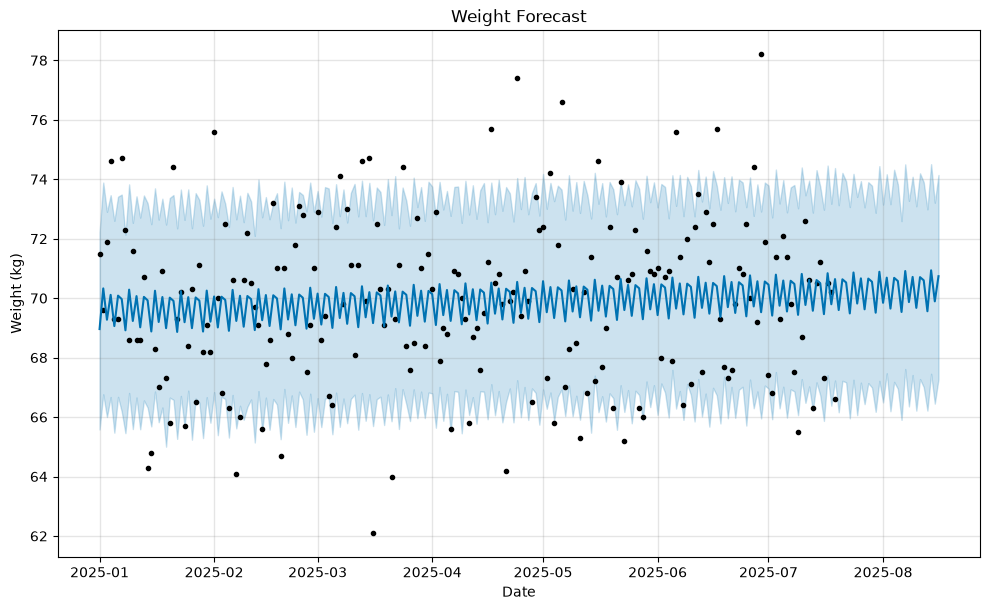

In [77]:
fig = generate_forecast_chart(model, forecast)

## 3.5 Trend/seasonality decomposition

Worth actually looking at, not skipping - explains WHY Prophet is forecasting what it's forecasting (trend vs. weekly pattern separately).

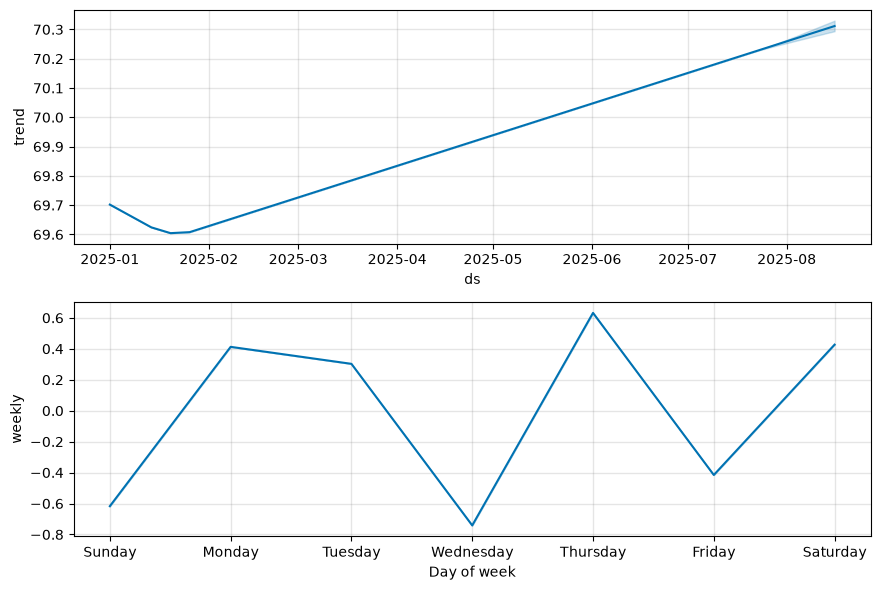

In [78]:
fig2 = model.plot_components(forecast)

## 3.6 Human-readable summary

In [79]:
print(get_forecast_summary(forecast))

# Optionally, with a target weight:
# print(get_forecast_summary(forecast, target_weight=65))

At your current trend, your projected weight around August 16, 2025 is approximately 70.7 kg (range: 67.3–74.1 kg).


## 3.7 Notes for your README

- Does the weekly seasonality component show anything interesting?
- How wide is the confidence interval by day 28? A wide band is honest uncertainty, not a bug.
- Known limitation: Prophet doesn't know this data is partly synthetic, and can't anticipate deliberate future changes (new diet plan, injury, etc.) - it only extrapolates from the pattern already seen.

In [80]:
# Your notes here

---
# PART 4 - Analytics + Correlation

Still using `DEMO_USER_ID` from the top of the notebook.

## 4.1 Sanity-check each analytics function

In [81]:
adherence_df = get_weekly_adherence(DEMO_USER_ID)
print(f"Weekly adherence  - {len(adherence_df)} weeks:")
print(adherence_df)
assert not adherence_df.empty, "FAILED: no adherence data  - check DEMO_USER_ID"
assert adherence_df['adherence_pct'].between(0, 100).all(), "FAILED: adherence_pct out of 0-100 range"

Weekly adherence  - 29 weeks:
      week  days_logged  workouts_completed  adherence_pct
0   202452            4                 4.0          100.0
1   202501            7                 7.0          100.0
2   202502            7                 7.0          100.0
3   202503            7                 7.0          100.0
4   202504            7                 7.0          100.0
5   202505            7                 7.0          100.0
6   202506            7                 7.0          100.0
7   202507            7                 7.0          100.0
8   202508            7                 7.0          100.0
9   202509            7                 7.0          100.0
10  202510            7                 7.0          100.0
11  202511            7                 7.0          100.0
12  202512            7                 7.0          100.0
13  202513            7                 7.0          100.0
14  202514            7                 7.0          100.0
15  202515            7   

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


In [82]:
rolling_df = get_rolling_weight_trend(DEMO_USER_ID)
print(f"Rolling weight trend  - {len(rolling_df)} days:")
print(rolling_df.head(10))
assert not rolling_df.empty, "FAILED: no weight trend data"
assert rolling_df['rolling_7day_avg'].notna().any(), "FAILED: rolling average is all null"

Rolling weight trend  - 200 days:
     log_date  weight_kg  rolling_7day_avg
0  2025-01-01       71.5             71.50
1  2025-01-02       69.6             70.55
2  2025-01-03       71.9             71.00
3  2025-01-04       74.6             71.90
4  2025-01-05       69.3             71.38
5  2025-01-06       69.3             71.03
6  2025-01-07       74.7             71.56
7  2025-01-08       72.3             71.67
8  2025-01-09       68.6             71.53
9  2025-01-10       71.6             71.49


c:\Users\Divya\Documents\workout_planner\modules\analytics.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


In [83]:
activity_df = get_weekly_activity(DEMO_USER_ID)
print(f"Weekly activity  - {len(activity_df)} weeks:")
print(activity_df)
assert not activity_df.empty, "FAILED: no activity data"
print("\nAll three analytics functions returned sensible data.")

Weekly activity  - 29 weeks:
      week  total_steps  avg_calories
0   202452      23341.0        2984.0
1   202501      51059.0        2689.0
2   202502      87689.0        2501.0
3   202503      55539.0        2278.0
4   202504      50218.0        2674.0
5   202505      59474.0        2608.0
6   202506      58919.0        2616.0
7   202507      51295.0        2826.0
8   202508      48071.0        2639.0
9   202509      61348.0        2509.0
10  202510      60286.0        2698.0
11  202511      36909.0        2837.0
12  202512      66676.0        2907.0
13  202513      67621.0        2860.0
14  202514      75355.0        2846.0
15  202515      59358.0        2572.0
16  202516      49863.0        2929.0
17  202517      68159.0        2631.0
18  202518      63026.0        2451.0
19  202519      40909.0        2573.0
20  202520      50484.0        2905.0
21  202521      61174.0        2557.0
22  202522      59861.0        2696.0
23  202523      68767.0        2997.0
24  202524      65725

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


## 4.2 Quick visual check - rolling weight trend

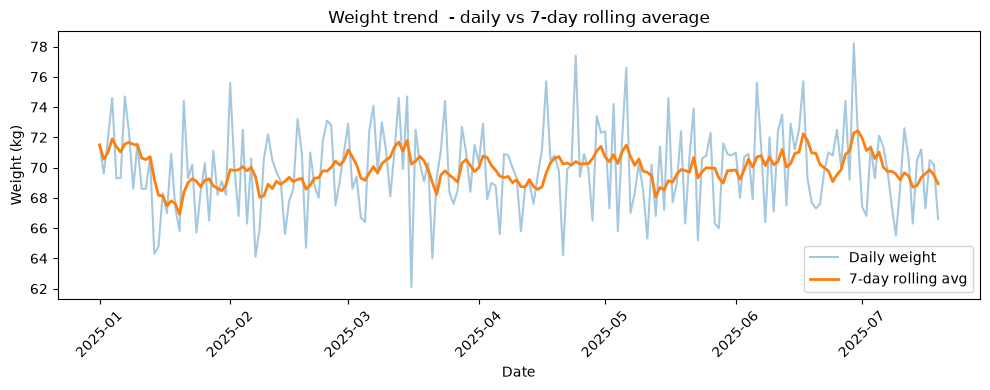

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolling_df['log_date'], rolling_df['weight_kg'], label='Daily weight', alpha=0.4)
ax.plot(rolling_df['log_date'], rolling_df['rolling_7day_avg'], label='7-day rolling avg', linewidth=2)
ax.set_xlabel('Date')
ax.set_ylabel('Weight (kg)')
ax.set_title('Weight trend  - daily vs 7-day rolling average')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.3 Build the adherence-vs-weight-change dataset

In [85]:
rolling_df['log_date'] = pd.to_datetime(rolling_df['log_date'])
rolling_df['week'] = rolling_df['log_date'].dt.strftime('%Y%W').astype(int)

weekly_weight_change = (
    rolling_df.groupby('week')['weight_kg']
    .agg(['first', 'last'])
    .assign(weight_change=lambda d: d['last'] - d['first'])
    .reset_index()[['week', 'weight_change']]
)

merged = pd.merge(adherence_df, weekly_weight_change, on='week', how='inner')
print(f"Merged dataset  - {len(merged)} weeks with both adherence and weight-change data:")
print(merged[['week', 'adherence_pct', 'weight_change']])

assert len(merged) >= 3, "Need at least 3 overlapping weeks for a meaningful correlation"

Merged dataset  - 28 weeks with both adherence and weight-change data:
      week  adherence_pct  weight_change
0   202501          100.0           -0.7
1   202502          100.0           -3.4
2   202503          100.0            4.5
3   202504          100.0            3.5
4   202505          100.0            3.8
5   202506          100.0           -3.6
6   202507          100.0           -1.4
7   202508          100.0           -4.5
8   202509          100.0            3.6
9   202510          100.0           -9.0
10  202511          100.0           -1.4
11  202512          100.0           -6.0
12  202513          100.0           -5.9
13  202514          100.0           -1.9
14  202515          100.0            2.2
15  202516          100.0            5.7
16  202517          100.0           -0.7
17  202518          100.0           -6.5
18  202519          100.0           -1.2
19  202520          100.0           -1.6
20  202521          100.0           -1.3
21  202522          100.0  

## 4.4 Run the correlation (adherence vs weight change)

Guards against a constant column - Pearson correlation is mathematically undefined when a
variable never varies (e.g. this seed dataset logs a workout every single day, making
adherence_pct constant at 100%). That's a real property of the demo data, not a bug.

In [86]:
if merged['adherence_pct'].nunique() == 1:
    print(f"adherence_pct is constant at {merged['adherence_pct'].iloc[0]}% across all weeks in this dataset.")
    print("Correlation is undefined when a variable has no variance  - this reflects a real property")
    print("of the seed data (a workout was logged every day), not a bug in the analysis.")
    correlation, p_value = None, None
else:
    correlation, p_value = stats.pearsonr(merged['adherence_pct'], merged['weight_change'])
    print(f"Pearson correlation coefficient: {correlation:.3f}")
    print(f"P-value: {p_value:.3f}")
    significance = "statistically significant (p < 0.05)" if p_value < 0.05 else \
        "NOT statistically significant (p >= 0.05)  - likely due to small sample size"
    print(f"\nThis result is {significance}.")

adherence_pct is constant at 100.0% across all weeks in this dataset.
Correlation is undefined when a variable has no variance  - this reflects a real property
of the seed data (a workout was logged every day), not a bug in the analysis.


## 4.5 Fallback correlation - calories vs weight change

Same technique, applied to a variable that actually varies in this dataset - a working
demonstration of the method even when adherence itself is constant.

In [87]:
merged_calories = pd.merge(activity_df, weekly_weight_change, on='week', how='inner')

correlation2, p_value2 = stats.pearsonr(merged_calories['avg_calories'], merged_calories['weight_change'])
print(f"Calories vs weight change  - Pearson correlation: {correlation2:.3f}, p-value: {p_value2:.3f}")

significance2 = "statistically significant (p < 0.05)" if p_value2 < 0.05 else \
    "NOT statistically significant (p >= 0.05)  - likely due to small sample size"
print(f"This result is {significance2}.")

Calories vs weight change  - Pearson correlation: -0.220, p-value: 0.261
This result is NOT statistically significant (p >= 0.05)  - likely due to small sample size.


## 4.6 Interpretation - fill this in for your README

- Adherence was constant in this seed dataset - note why, and that this is a data limitation, not an analysis bug.
- For the calories-vs-weight-change result: what direction, and does it match expectations?
- Statistically significant given the amount of data available?
- Correlation isn't causation - what confounds could explain the result either way?
- This is largely synthetic seed data - how much should this specific result be trusted vs. treated as a demonstration of the technique?

In [88]:
# Your interpretation notes here

---
# PART 5 - Form Checker

Two stages:
1. Test `calculate_angle()` standalone with hand-picked coordinates - before trusting it on real video, so a bug here doesn't hide inside frames of confusing output.
2. Run the full pipeline on real recorded videos for squat, deadlift, and push-up.

**Before 5.2:** record short videos (10-20 seconds, side angle, 3-5 reps each) and set the `VIDEO_PATH` variables below.

## 5.1 Test the angle math with known coordinates

Simple, hand-checkable points you can verify yourself with basic geometry, before trusting the function on real landmark data.

In [89]:
# A straight line (b directly between a and c) should be ~180 degrees
a = (0, 0)
b = (1, 0)
c = (2, 0)
angle = calculate_angle(a, b, c)
print(f"Straight line angle: {angle:.1f} (expected ~180)")
assert abs(angle - 180) < 1, "FAILED: straight line should be ~180 degrees"

Straight line angle: 180.0 (expected ~180)


In [90]:
# A right angle: a straight up from b, c straight right from b
a = (0, -1)
b = (0, 0)
c = (1, 0)
angle = calculate_angle(a, b, c)
print(f"Right angle: {angle:.1f} (expected ~90)")
assert abs(angle - 90) < 1, "FAILED: should be ~90 degrees"

Right angle: 90.0 (expected ~90)


In [91]:
# Simulate a rough squat knee angle: hip above knee, ankle below knee,
# knee bent forward slightly  - should land somewhere clearly under 180.
hip = (0.5, 0.3)
knee = (0.55, 0.6)
ankle = (0.5, 0.9)
angle = calculate_angle(hip, knee, ankle)
print(f"Simulated bent-knee angle: {angle:.1f}")
assert 0 < angle < 180, "FAILED: angle out of valid range"
print("\nAll angle math checks passed  - safe to trust calculate_angle() on real data now.")

Simulated bent-knee angle: 161.1

All angle math checks passed  - safe to trust calculate_angle() on real data now.


## 5.2 Squat - full pipeline on a real video

In [92]:
VIDEO_PATH = "data/SquatFormTest.mp4"

results = process_video(VIDEO_PATH, exercise_type="squat", frame_skip=2)

print(f"Detected {len(results)} reps:\n")
for rep in results:
    print(f"  Rep {rep['rep_number']}: peak angle {rep['peak_angle']}°  - {rep['verdict']}  - {rep['feedback']}")

c:\Users\Divya\Documents\workout_planner\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Detected 6 reps:

  Rep 1: peak angle 46.1°  - good_depth  - Good depth.
  Rep 2: peak angle 44.3°  - good_depth  - Good depth.
  Rep 3: peak angle 42.7°  - good_depth  - Good depth.
  Rep 4: peak angle 53.0°  - good_depth  - Good depth.
  Rep 5: peak angle 50.2°  - good_depth  - Good depth.
  Rep 6: peak angle 48.4°  - good_depth  - Good depth.


### Does the rep count look right?

Compare `len(results)` against how many squats you actually did.
- **Undercounting** - thresholds might be too strict, or `frame_skip` too high, missing transition frames.
- **Overcounting** - thresholds too loose, or noisy landmark detection causing the angle to jitter across the threshold.

This is expected tuning work - thresholds in `exercise_rules.py` are starting points, not final.

## 5.3 Deadlift - full pipeline on a real video

In [93]:
VIDEO_PATH = "data/DeadliftExample.mp4"

results = process_video(VIDEO_PATH, exercise_type="deadlift", frame_skip=2)

print(f"Detected {len(results)} reps:\n")
for rep in results:
    print(f"  Rep {rep['rep_number']}: peak angle {rep['peak_angle']}°  - {rep['verdict']}  - {rep['feedback']}")

Detected 2 reps:

  Rep 1: peak angle 24.1°  - good_depth  - Good hip hinge depth.
  Rep 2: peak angle 26.2°  - good_depth  - Good hip hinge depth.


## 5.4 Push-up - full pipeline on a real video

In [94]:
VIDEO_PATH = "data/PushupsExample.mp4"

results = process_video(VIDEO_PATH, exercise_type="push_up", frame_skip=2)

print(f"Detected {len(results)} reps:\n")
for rep in results:
    print(f"  Rep {rep['rep_number']}: peak angle {rep['peak_angle']}°  - {rep['verdict']}  - {rep['feedback']}")

Detected 8 reps:

  Rep 1: peak angle 48.2°  - good_depth  - Good depth.
  Rep 2: peak angle 49.3°  - good_depth  - Good depth.
  Rep 3: peak angle 49.2°  - good_depth  - Good depth.
  Rep 4: peak angle 50.9°  - good_depth  - Good depth.
  Rep 5: peak angle 51.6°  - good_depth  - Good depth.
  Rep 6: peak angle 51.0°  - good_depth  - Good depth.
  Rep 7: peak angle 53.7°  - good_depth  - Good depth.
  Rep 8: peak angle 57.7°  - good_depth  - Good depth.


### 5.5 Threshold tuning notes

Record what you observed for each exercise - over/under-counting, whether verdicts matched what you actually felt/saw in the video. This becomes real evidence of iterative tuning for your README.

In [95]:
# Your tuning notes here

---
## General notes / observations